# Latency / size regimes

Deck slides 10–20 → `hftpat.size_latency_panel`.  
Slice: **ETH** · HL+Deribit+Kraken · `out/latency_size_regimes/`.  
**Kill:** co-lo µs claims, Hibernia Express, fiber distance vanity.


In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

BOOK = Path(os.environ.get("ARES_MICROSTRUCTURE") or (Path.home() / "srv" / "ares-microstructure")) / 'research' / 'books' / 'filmonov'
OUT = BOOK / 'out' / 'latency_size_regimes'
FIGS = OUT / 'figs'
panel = json.loads((OUT / 'panel.json').read_text())
summary = json.loads((OUT / 'summary.json').read_text())
print('days', panel['days'], 'n_complete', summary['n_complete'], '/', summary['n_venue_days'])
flat = []
for r in panel['rows']:
    p = r.get('panel') or {}
    flat.append({
        'venue': r['venue'], 'day': r['day'],
        'complete': r['completeness']['complete'],
        'tob_ok': r['tob_ok'], 'tob_synth': r.get('tob_synth'),
        'tob_hz': p.get('tob_update_hz'),
        'tob_dt_ms': p.get('tob_median_dt_ms'),
        'trade_hz': p.get('trade_hz'),
        'size_q50': (p.get('size_quantiles') or {}).get('q50'),
        'size_q99': (p.get('size_quantiles') or {}).get('q99'),
        'n_trades': r['n_trades'],
    })
df = pd.DataFrame(flat)
print(df.groupby('venue')[['tob_hz','tob_dt_ms','trade_hz','size_q50']].median())



days ['2026-09-26', '2026-09-27', '2026-09-30'] n_complete 9 / 9
               tob_hz    tob_dt_ms  trade_hz  size_q50
venue                                                 
deribit      0.323586  2544.000000  0.567789   150.000
hyperliquid  0.186254  5389.999872  1.214664     0.105
kraken       0.171561  3242.000128  0.929251     0.020


## Trade-size medians by venue-day



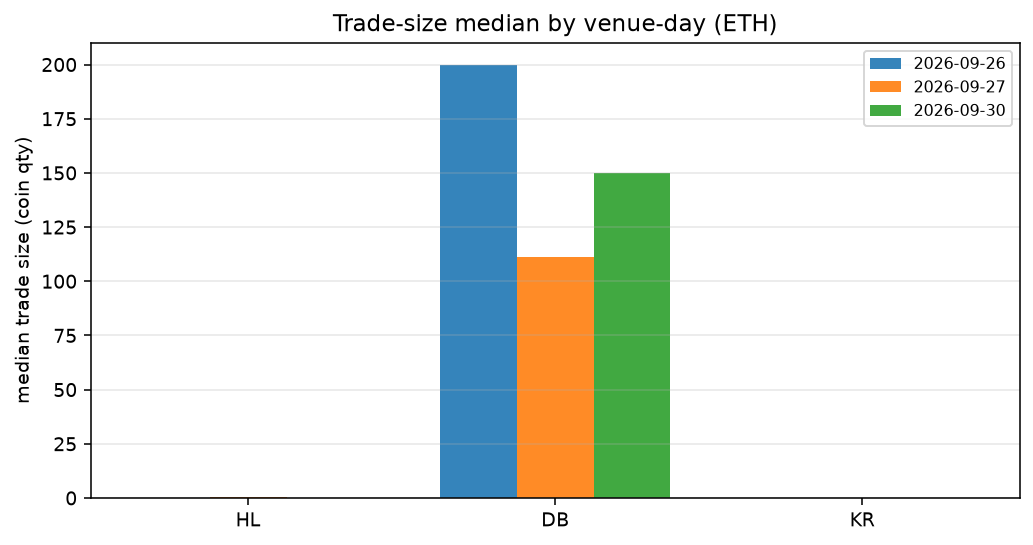

In [2]:
display(Image(filename=str(FIGS / 'fig_size_quantiles.png')))



## TOB update Hz (reaction-time proxy)



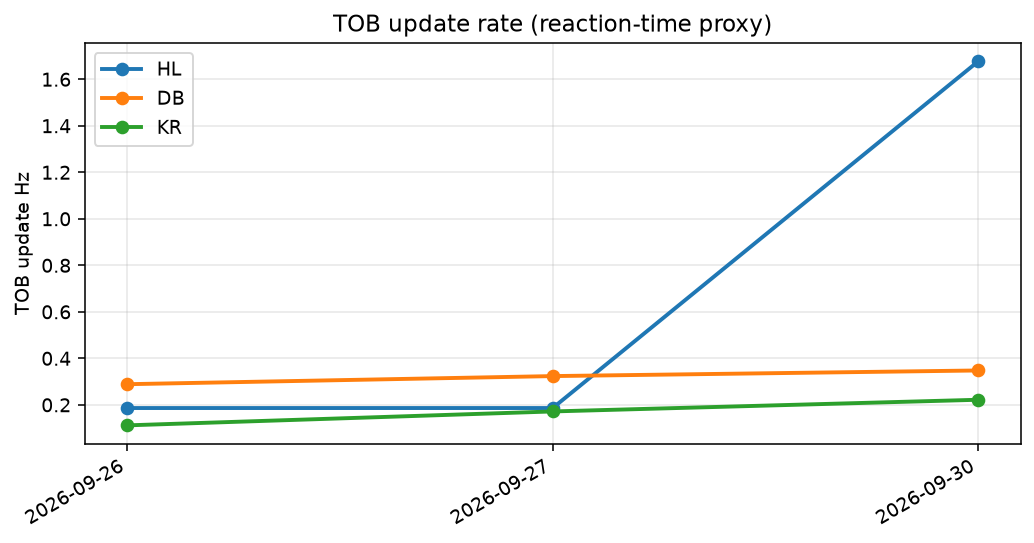

In [3]:
display(Image(filename=str(FIGS / 'fig_tob_hz.png')))



## Regime scatter + size quantile curve



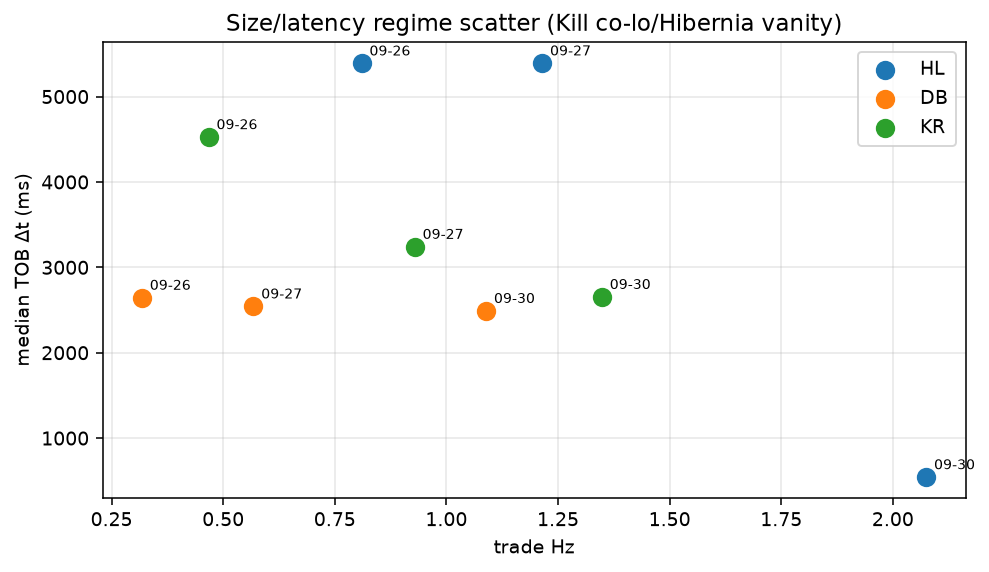

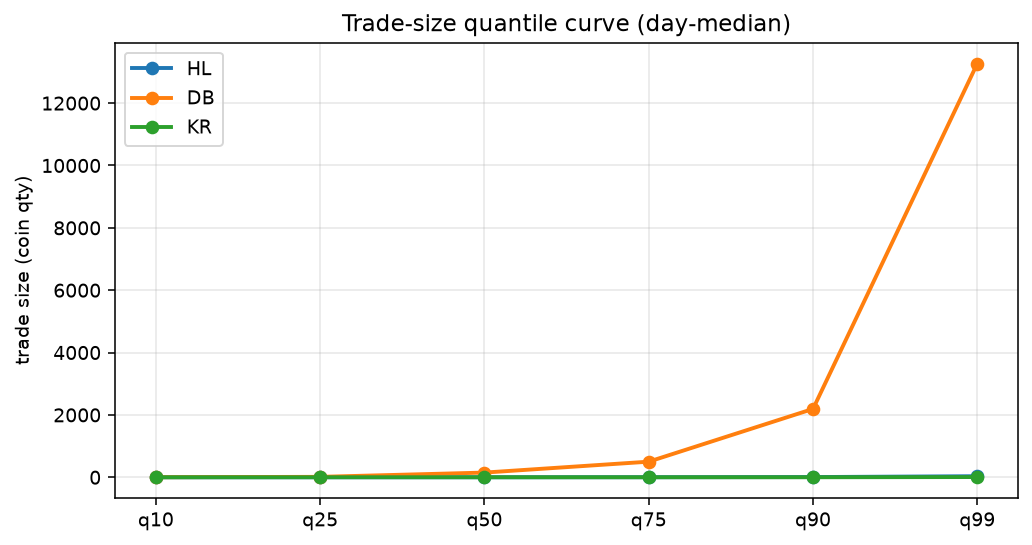

In [4]:
display(Image(filename=str(FIGS / 'fig_reaction_proxy.png')))
display(Image(filename=str(FIGS / 'fig_size_curve.png')))



## Candidates (Pass 1 draft)

- `mm.size_latency_regime_panel` — **Hold** (monitor; Pass 2 bootstrap)
- `id.colo_rtt_40us_claim` / `id.hibernia_express_6ms` / `id.fiber_distance_table` — **Kill**

